## Imports

In [1]:
import json
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

In [2]:
lasso_or_knn = "knn"

## Load scores and plotting metadata

In [3]:
df = pd.read_csv("/home/jovyan/pert-bench-fusion-paper/results/scores/essential_lfc.csv", index_col=0)

In [4]:
with open("/home/jovyan/pert-bench-fusion-paper/results/metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

method_map = {
    k.replace("HEAD_TYPE", lasso_or_knn): v
    for k, v in fig_index["essential_lfc"].items()
}
model_type_palette = fig_index['genes_model_type_palette']
hue_order = fig_index['genes_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])

## Rankings

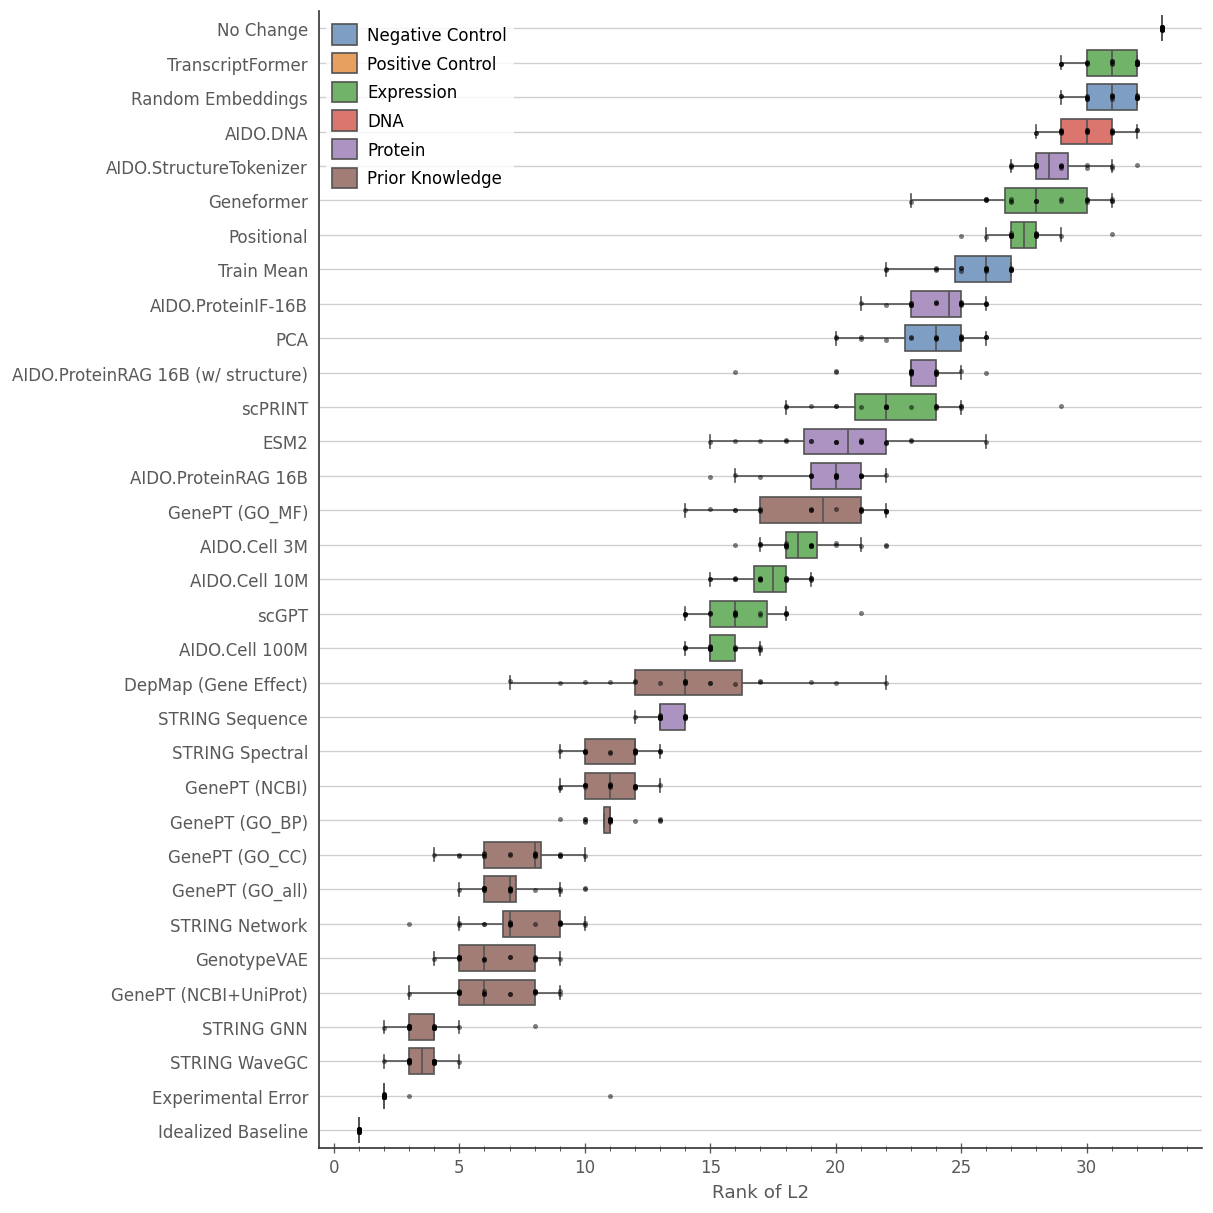

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)

# Build the aggregated dataframe of ranks
df_list = []
for i, cell_line in enumerate(["K-562", "Hep-G2", "Jurkat", "hTERT-RPE1"]):
    method_list = [e.replace("CELL_LINE", cell_line) for e in method_map]
    idx = df["fold"].str.contains(cell_line) & df["name"].isin(method_list)
    df_subset = df[idx].copy()
    df_subset["name"] = df_subset["name"].str.replace(cell_line, "CELL_LINE")
    df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
    df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])
    df_list.append(df_subset)
df_subset = pd.concat(df_list)
df_subset["L2"] = df_subset.groupby("fold")["L2"].rank()

present_hues = [
    h for h in hue_order
    if h in df_subset["Model type"].unique()
]

# Boxplot
order=df_subset.groupby("name")["L2"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df_subset, y="name", x="L2", order=order, ax=ax, hue="Model type", hue_order=present_hues, width=0.75, palette=model_type_palette, showfliers=False)
sns.stripplot(data=df_subset, y="name", x="L2", order=order, ax=ax, s=3, alpha=0.5, color="black", jitter=.05)

# Decorate
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.set_ylabel("")
ax.set_xlabel(f"Rank of {"L2"}")
ax.grid(axis="y")
sns.despine(fig)
plt.savefig("fig_2.pdf")